# REWARD GRADIENT MAP IMPLEMENTATION

I will try to design a reward map where every datapoint encodes some kind of reward. 

In [2]:
# libraries needed

import numpy as np
import matplotlib.pyplot as plt
import random
from matplotlib import cm
from tqdm import tqdm

In [6]:
def plot_results (X, Y, reward_map, grid_size):
    fig = plt.figure(figsize=(22, 10))
    fig.suptitle("Reward map")
    ax1 = fig.add_subplot(1,2,1,projection='3d')
    
    ax1.plot_surface(X, Y, reward_map, rstride=3, cstride=3, linewidth=1, antialiased=True,
                    cmap=cm.viridis)
    ax1.view_init(25, -55) # elevation, azimut, roll
    ax1.set_xticks(np.linspace(0, grid_size, 6))
    ax1.set_yticks(np.linspace(0, grid_size, 6))
    #ax1.set_zticks([])
    ax1.set_ylim(0.0001)
    ax1.set_xlabel(r'$X$')
    ax1.set_ylabel(r'$Y$')
    plt.title("3D")
    
    ax2 = fig.add_subplot(1,2,2,projection='3d')
    ax2.contourf(X, Y, reward_map, zdir='z', offset=0, cmap=cm.viridis)
    ax2.view_init(90, 0)
    
    ax2.grid(True)
    ax2.set_xticks(np.linspace(0, grid_size, 6))
    ax2.set_yticks(np.linspace(0, grid_size, 6))
    ax2.set_zticks([])
    ax2.set_xlabel(r'$X$')
    ax2.set_ylabel(r'$Y$')
    
    plt.title("Heatmap")
    
    return plt.show()

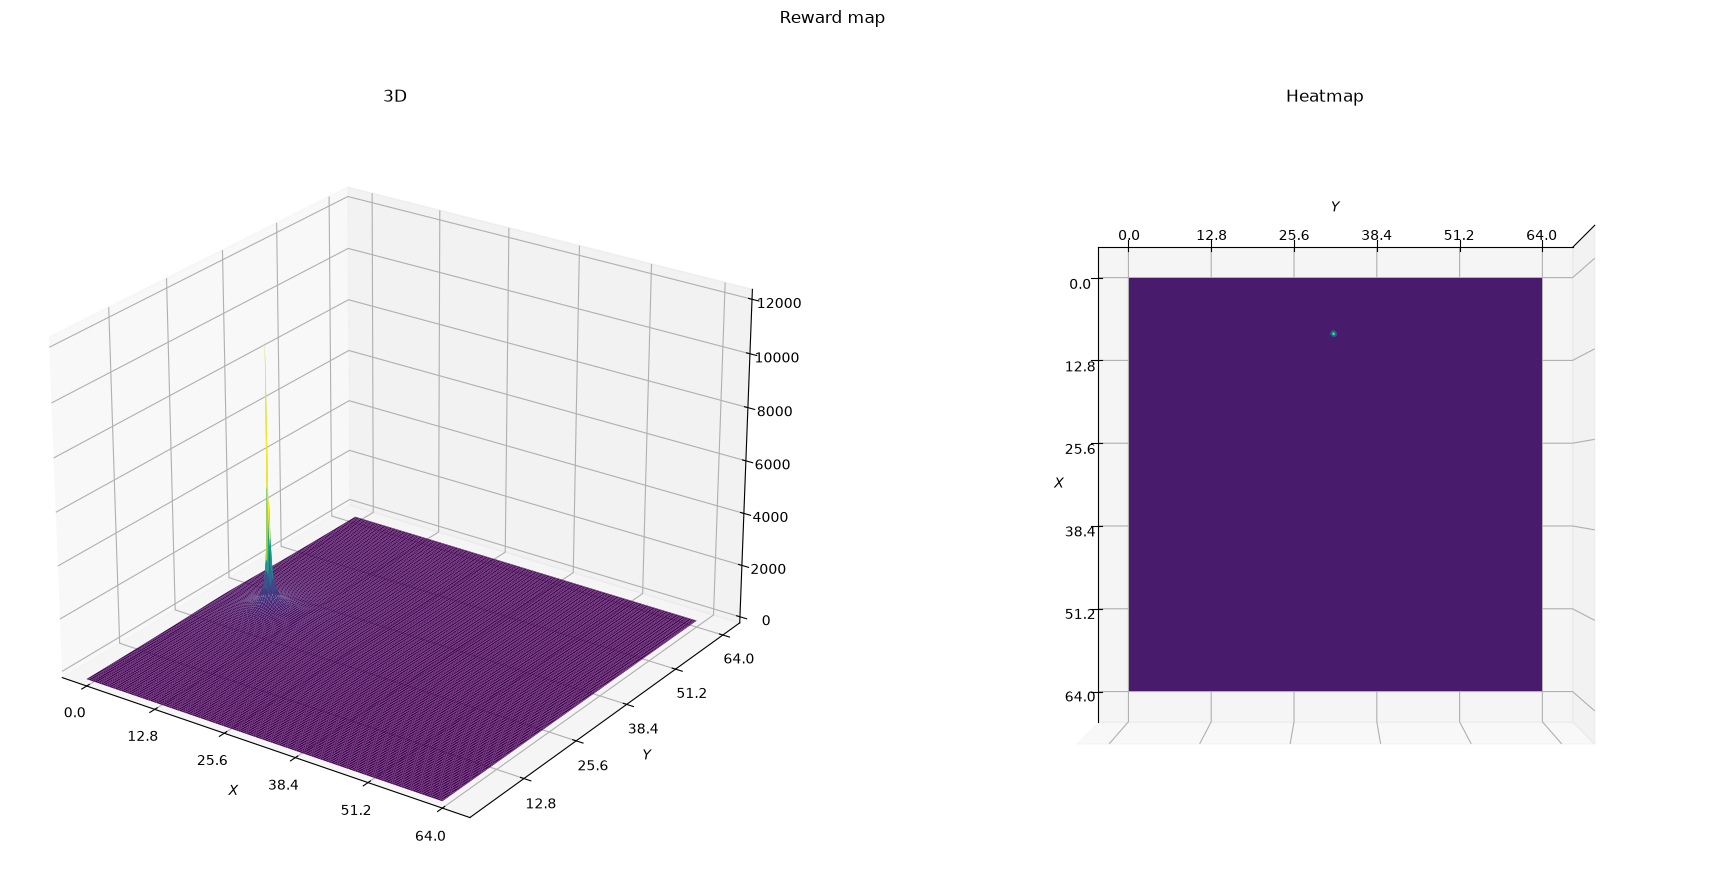

In [32]:
grid_size = 64
X = np.linspace(0, grid_size, 500)
Y = np.linspace(0, grid_size, 500)
X, Y = np.meshgrid(X, Y)
size_of_food = 1 # size of the sphere that is the food 
# assume a particular constant A 
A = 900
# declare a zeros matrix to which our values will be added 
reward_map = np.zeros((len(X), len(Y)))
# pick a random point for the food source 
food_x = np.random.uniform(2, grid_size - 2)
food_y = np.random.uniform(2, grid_size - 2)

dff = np.sqrt((X-food_x)**2 + (Y-food_y)**2) + 0.0001 # slight addition to avoid division by 0

reward_map = A/dff
plot_results(X, Y, reward_map, grid_size)

## Exponential decay 

Here a solution with exponential decay is proposed, following the following formula 

$C(r) = C_0e^{\frac{-r}{\lambda}}$

where:

$C_0$ = concentration at the source  

$r$ = distance  

$\lambda$ = smell range (decay length).

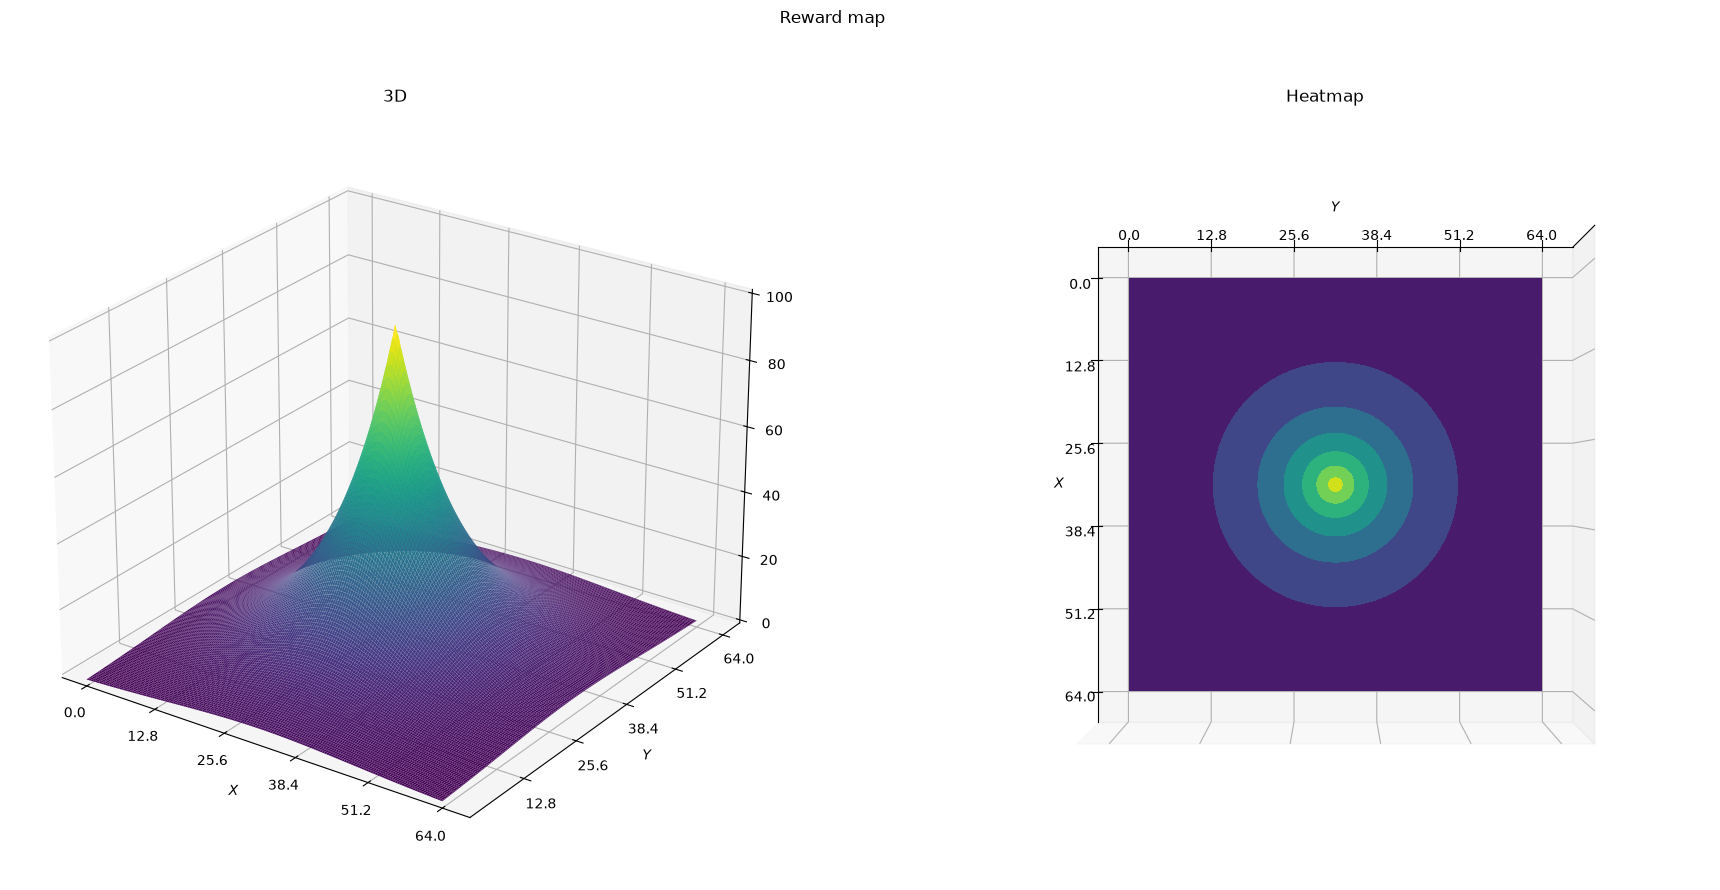

In [51]:
grid_size = 64
C_0 = 100
decay_length = 10
# pick a random point for the food source 
food_x = 32 #np.random.uniform(2, grid_size - 2)
food_y = 32 #np.random.uniform(2, grid_size - 2)

dff = np.sqrt((X-food_x)**2 + (Y-food_y)**2)

reward_map = C_0 * np.exp(-dff/decay_length)
plot_results(X, Y, reward_map, grid_size)

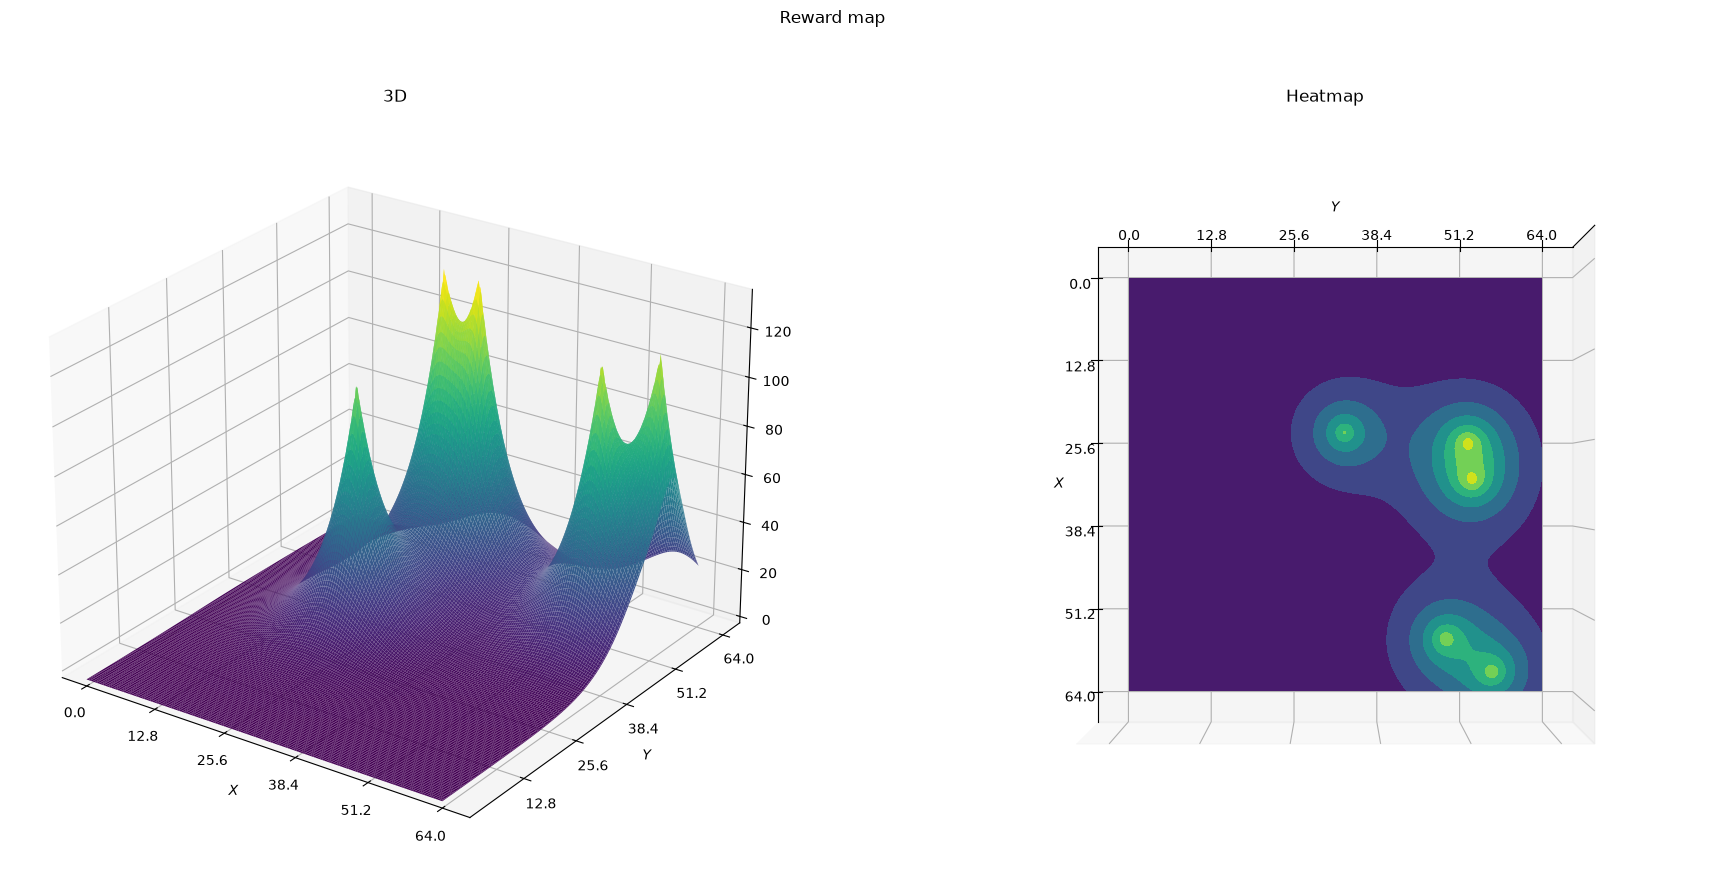

In [47]:
grid_size = 64
C_0 = 100
decay_length = 5

# now implement it for multiple rewards 

n_rewards = 5
reward_map = np.zeros_like(X)
for r in range(n_rewards): 
    food_x = np.random.uniform(2, grid_size - 2)
    food_y = np.random.uniform(2, grid_size - 2)
    
    dff = np.sqrt((X-food_x)**2 + (Y-food_y)**2) #add the x and y components to the respective coordinate fields
    reward_map += C_0 * np.exp(-dff/decay_length) #

plot_results(X, Y, reward_map, grid_size)
